For Project 3, we are operating under the following scenario:

An external online retail company, Le Shoppe, has requested assistance with identifying customers who may previously have shopped with their business, but haven't come back in a while.

They currently have limited outreach to these customers. 
- Once a year, their Marketing team runs a "welcome back" campaign where they send an email with a special discount code to customers who haven't shopped with them in 12 months.
- During quiet periods (when there aren't a lot of calls or tickets to respond to), their Customer Care team members are given a list to work from containing customer details who have been less active. The Customer Care team reach out to these customers and make contact with them, and are authorised to give them discounts and freebies where needed.

This company, Le Shoppe, has noticed recently that this is not the most effective means of reaching out to or identifying these customers. Both methods require a manual pull of a list from the system each time they need that list, and it requires someone on these teams with the knowledge and authority within the business to pull said list. The list may also be outdated by the time it reaches a customer care team member, or a resulting special offer has reached a customer.

The company is also unclear on what may be causing customers to stop shopping with them beyond individual feedback they have received from customers themselves. 

Le Shoppe has three primary goals for this particular endeavour:
1. A better process for identifying customers at risk of churning
2. Where possible, locate the underlying trend(s) that may be causing customers to churn
3. Suggestions and recommendations on how to improve their service to these customers

The primary stakeholders within Le Shoppe are the General Marketing Manager, the Customer Care Manager, and the Ecommerce Operations Manager.

## Marking Criteria (Notebook, 35%)
>  - A single professional and structured Jupyter notebook (pretend that you are submitting this to a potential client)
> - Include some EDA where needed, but focus primarily on robust experimentation with feature engineering, a variety of algorithms
> and their tuning, XAI, and providing rich analysis and interpretation at each step.
> - Make sure that you use a rich array of evaluation metrics and present all your modelling and accuracies from different approaches effectively.

In [166]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [167]:
churn_dataset = pd.read_csv('frankendata/ecommerce_churn.csv')

In [168]:
churn_dataset.dtypes

Age                              float64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Signup_Quarter  

In [169]:
churn_dataset.isna().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

How many of these features are 'important' (and how many of them can I just delete if they're not and contain too many NaNs)?

In [170]:
# Random Forest Classifier doesn't like categorical values
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(churn_dataset[['Gender','Country','City','Signup_Quarter']])

encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Gender','Country','City','Signup_Quarter']))
churn_dataset_encoded = churn_dataset.drop(['Gender','Country','City','Signup_Quarter'], axis=1)
churn_dataset_encoded = pd.concat([churn_dataset_encoded, encoded_df], axis=1)

In [171]:
y = churn_dataset_encoded['Churned']
X = churn_dataset_encoded.drop('Churned', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [172]:
rf_helper = RandomForestClassifier(n_estimators=100, random_state=42)
rf_helper.fit(X_train, y_train)

importances = rf_helper.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

In [173]:
top20feature_importance_df = feature_importance_df.head(20)
top20feature_importance_df

,Feature,Importance
18,Lifetime_Value,0.111573
13,Customer_Service_Calls,0.104860
5,Cart_Abandonment_Rate,0.081476
0,Age,0.062750
10,Discount_Usage_Rate,0.057891
9,Days_Since_Last_Purchase,0.051831
12,Email_Open_Rate,0.046456
8,Average_Order_Value,0.044633
7,Total_Purchases,0.043806
3,Session_Duration_Avg,0.042794


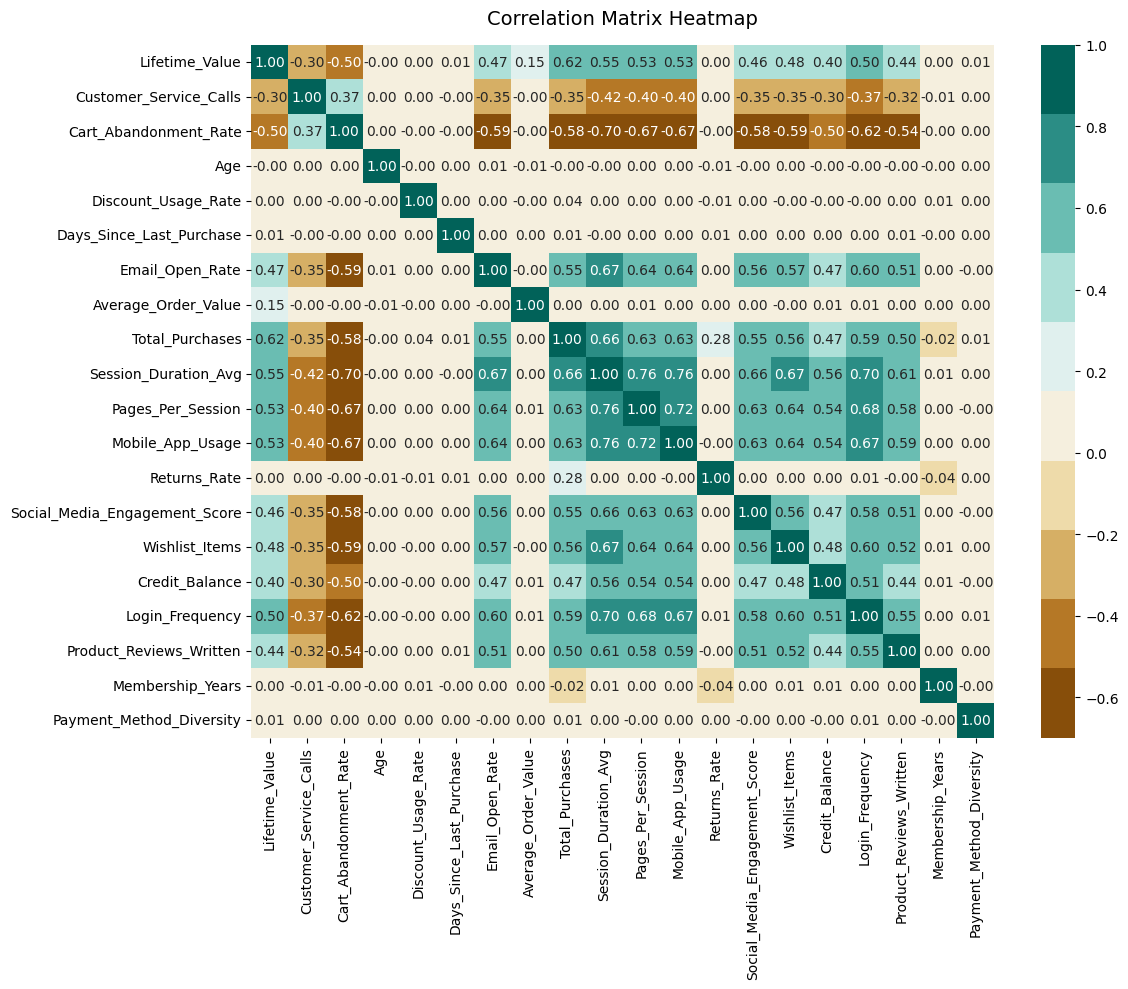

In [174]:
feature_names_top20 = top20feature_importance_df['Feature'].tolist()

corr_matrix = churn_dataset_encoded[feature_names_top20].corr()

plt.figure(figsize=(12, 10))
colormap = sns.color_palette("BrBG",10)

# Draw the heatmap
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap=colormap)

plt.title("Correlation Matrix Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Based on the above diagnostics, these are the best features to select/work with, so far:

**Strongest feature:** Lifetime_Value

**Supporting features (highest correlation):**
- Total_Purchases
- Session_Duration_Average
- Pages_Per_Session
- Mobile_App_Usage
- Login_Frequency
- Cart_Abandonment_Rate

**Possibly Helpful/Remains to be seen (moderate correlation)**
- Social_Media_Engagement_Score
- Wishlist_Items
- Credit_Balance
- Product_Reviews_Written
- Email_Open_Rate

**Questionable/Not Super Helpful (low correlation):**
- Average_Order_Value
- Returns_Rate
- Customer_Service_Calls

**Features we can absolutely drop (nil or next-to-nil correlation):**
- Age
- Discount_Usage_Rate
- Days_Since_Last_Purchase
- Membership_Years
- Payment_Method_Diversity

In [175]:
columns_to_initially_keep = ['Gender','Country','City'] + feature_names_top20 + ['Churned']
churn_df = churn_dataset[columns_to_initially_keep]
columns_to_drop = ['Age','Discount_Usage_Rate','Days_Since_Last_Purchase','Membership_Years','Payment_Method_Diversity']
churn_df = churn_df.drop(columns=columns_to_drop)
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Gender                         50000 non-null  object 
 1   Country                        50000 non-null  object 
 2   City                           50000 non-null  object 
 3   Lifetime_Value                 50000 non-null  float64
 4   Customer_Service_Calls         49832 non-null  float64
 5   Cart_Abandonment_Rate          50000 non-null  float64
 6   Email_Open_Rate                47472 non-null  float64
 7   Average_Order_Value            50000 non-null  float64
 8   Total_Purchases                50000 non-null  float64
 9   Session_Duration_Avg           46601 non-null  float64
 10  Pages_Per_Session              47000 non-null  float64
 11  Mobile_App_Usage               45000 non-null  float64
 12  Returns_Rate                   45509 non-null 

---

# Risk Group Identification

## Kmeans Clustering

As a means of identifying how to split our dataset for prediction analysis, I am employing the KMeans Clustering algorithm to see how we can best segregate the customers, and how many groups we can split them into.

In [176]:
# Keep only continuous labels (no categorical/encoded)
# Drop the nil correlations
kmeans_df = churn_dataset.drop(columns=['Age','Gender','Country','City','Signup_Quarter','Returns_Rate','Customer_Service_Calls','Discount_Usage_Rate','Days_Since_Last_Purchase','Membership_Years','Payment_Method_Diversity']).copy()
kmeans_df.dropna(inplace=True)
y_kmeans = kmeans_df['Churned']
X_kmeans = kmeans_df.drop('Churned', axis=1)

scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

Use indexing to see the optimal number of groups

In [177]:
k_range = range(2, 7) # Check range of 2 - 7 clusters
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in k_range:
    km_model = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km_model.fit(X_kmeans_scaled)
    results = km_model.predict(X_kmeans_scaled)

    silhouette_scores.append(metrics.silhouette_score(X_kmeans_scaled, results))
    davies_bouldin_scores.append(metrics.davies_bouldin_score(X_kmeans_scaled, results))
    calinski_harabasz_scores.append(metrics.calinski_harabasz_score(X_kmeans_scaled, results))

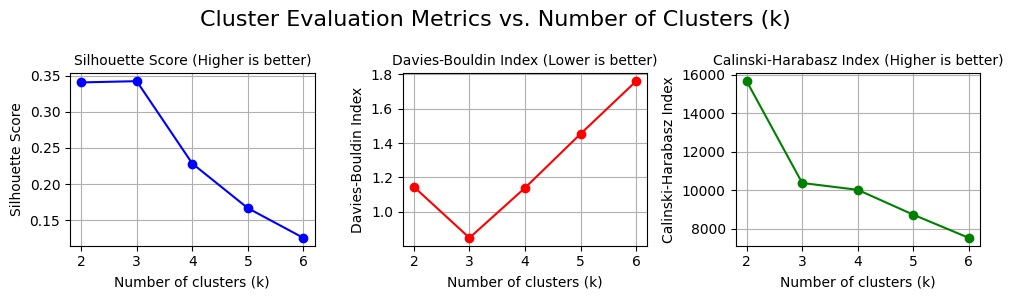

In [178]:
fig = plt.figure(figsize=(10, 3))
gs = gridspec.GridSpec(1, 3, figure=fig, height_ratios=[1])
fig.suptitle('Cluster Evaluation Metrics vs. Number of Clusters (k)', fontsize=16)

ax1 = fig.add_subplot(gs[0, 0]) # Row 0, Column 0
# Silhouette Plot
ax1.plot(k_range, silhouette_scores, 'bo-')
ax1.set_xlabel('Number of clusters (k)', fontsize=10)
ax1.set_ylabel('Silhouette Score', fontsize=10)
ax1.set_title('Silhouette Score (Higher is better)', fontsize=10)
ax1.grid(True)

ax2 = fig.add_subplot(gs[0, 1]) # Row 0, Column 1
# Davies-Bouldin Plot
ax2.plot(k_range, davies_bouldin_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)', fontsize=10)
ax2.set_ylabel('Davies-Bouldin Index', fontsize=10)
ax2.set_title('Davies-Bouldin Index (Lower is better)', fontsize=10)
ax2.grid(True)

ax3 = fig.add_subplot(gs[0, 2]) # Row 0, Column 2
# Calinski-Harabasz Plot
ax3.plot(k_range, calinski_harabasz_scores, 'go-')
ax3.set_xlabel('Number of clusters (k)', fontsize=10)
ax3.set_ylabel('Calinski-Harabasz Index', fontsize=10)
ax3.set_title('Calinski-Harabasz Index (Higher is better)', fontsize=10)
ax3.grid(True)

plt.tight_layout(); plt.show()

From the above plots, we can determine the optimal number for k is most likely 3. 3 is (just barely) the highest Silhouette Score, the lowest (preferred) option in the Davies-Bouldin Index, and the 'elbow' in the Calinski-Harabasz Index (where the rate of improvement is minimal past this point as k increases).

In [179]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X_kmeans_scaled)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_kmeans_scaled)

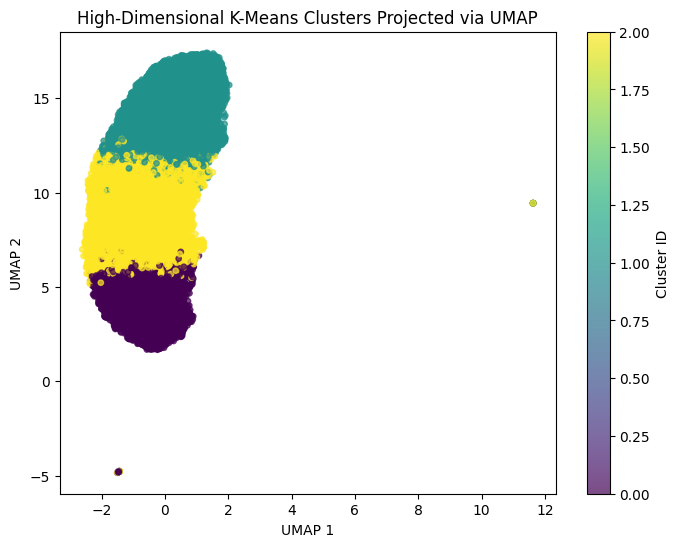

In [180]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0],X_umap[:, 1],c=cluster_labels,cmap="viridis",s=15,alpha=0.7)

plt.colorbar(scatter, label="Cluster ID")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("High-Dimensional K-Means Clusters Projected via UMAP")
plt.show()

In [181]:
kmean_groups = X_kmeans.copy()
kmean_groups['Cluster'] = cluster_labels
kmean_groups['Churned'] = y_kmeans

# Calculate the average values for each cluster
cluster_summary = kmean_groups.groupby('Cluster').mean()

cluster_summary.sort_values(by='Churned', ascending=True)

,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Email_Open_Rate,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Churned
Cluster,,,,,,,,,,,,,,
0,21.806452,42.495757,13.872504,36.393283,8.297811,21.736137,124.438648,38.357200,5.564324,54.891283,32.332911,2418.297368,3291.823541,0.201997
2,13.415014,29.804591,9.635571,52.970487,4.905891,14.513358,123.826362,23.239468,3.256446,33.214925,21.498294,1580.456803,2167.092324,0.202896
1,6.207202,18.755762,5.903835,68.151355,2.119927,8.313315,119.783651,10.988740,1.399858,15.588150,12.292107,907.719694,1249.041196,0.380328


In [182]:
risk_map = {0: "low", 1: "high", 2: "medium"}
kmean_groups['Churn_Risk'] = kmean_groups['Cluster'].map(risk_map)
kmean_groups.head(5)

,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Email_Open_Rate,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Lifetime_Value,Credit_Balance,Cluster,Churned,Churn_Risk
0,14.0,27.4,6.0,50.6,3.0,9.0,94.72,17.9,4.0,16.3,20.8,953.33,2278.0,2,0,medium
3,10.0,38.4,14.8,41.7,9.0,15.0,147.33,41.4,5.0,85.9,31.0,2340.92,2674.0,0,0,low
5,6.0,21.9,6.9,74.4,0.0,12.0,190.97,16.0,2.0,14.3,11.2,1995.43,2418.0,1,1,high
6,24.0,46.4,13.9,36.2,5.0,20.0,169.58,35.5,6.0,68.8,42.9,3003.57,2657.0,0,0,low
9,13.0,31.3,5.4,62.6,3.0,9.0,90.95,11.7,1.0,13.5,21.5,807.84,977.0,1,0,high
